# Supplementary Figure 10

Computational panels B–E.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch, Patch, Rectangle

# Locate the repository whether the notebook is run from the repo root or notebook/.
_start = Path.cwd().resolve()
ROOT = next(
    candidate
    for candidate in (_start, *_start.parents)
    if (candidate / "environment.yml").is_file()
)
DATA_DIR = ROOT / "src" / "manuscript_figures" / "figS10"
STYLE = ROOT / "src" / "manuscript_figures" / "style.mplstyle"
if STYLE.is_file():
    plt.style.use(STYLE)
mpl.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "text.parse_math": True,
    }
)

CHROME = {
    "ink": "#222222",
    "muted": "#666666",
    "axis": "#9CA3AF",
    "grid": "#E2E4E7",
    "bioagents": "#00838F",
}


def clean_axis(ax, grid_axis=None):
    ax.spines[["top", "right"]].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(CHROME["axis"])
        ax.spines[side].set_linewidth(0.6)
    ax.tick_params(length=3, width=0.55, colors=CHROME["muted"])
    if grid_axis:
        ax.grid(axis=grid_axis, color=CHROME["grid"], linewidth=0.6)
        ax.set_axisbelow(True)


In [2]:
B_TASK1 = pd.read_csv(DATA_DIR / "b" / "analysis" / "task1_per_target.csv")
B_TRAINING = pd.read_csv(
    DATA_DIR / "b" / "analysis" / "151_TH_Prkcd_Grin2c_Glut_deg_counts_training.csv"
)
C_FEATURED = pd.read_csv(
    DATA_DIR / "c" / "analysis" / "featured_overpredictions.csv"
)
C_NEIGHBORS = pd.read_csv(
    DATA_DIR / "c" / "analysis" / "featured_string_neighbors.csv"
)
D_HOLDOUTS = pd.read_csv(
    DATA_DIR / "d" / "analysis" / "holdout_depletion_rank_recovered_cells.csv"
)
E_FISHER = pd.read_csv(
    DATA_DIR / "e" / "analysis" / "fisher_results_151_TH_Prkcd_Grin2c_Glut.csv"
)
E_TOP150 = pd.read_csv(
    DATA_DIR / "e" / "analysis" / "top150_depletion_151_TH_Prkcd_Grin2c_Glut_predicted_group.csv"
)

assert len(B_TASK1) == 272 and B_TASK1["target_name"].is_unique
assert len(B_TRAINING) == 1_674 and B_TRAINING["target_name"].is_unique
assert C_FEATURED["target_name"].tolist() == [
    "Pomp", "Thoc2", "Pafah1b1", "Smc3", "Hnrnpa1", "Med12", "Taf1"
]
assert len(C_NEIGHBORS) == 48
assert len(D_HOLDOUTS) == 272 and D_HOLDOUTS["target_name"].is_unique
assert D_HOLDOUTS[
    ["actual_n_degs", "codex_predicted_n_degs", "bioagents_predicted_n_degs"]
].ge(0).all().all()
assert len(E_FISHER) == 1_948 and E_FISHER["gene_target"].is_unique
assert E_FISHER["cell_type"].eq("151 TH Prkcd Grin2c Glut").all()
assert len(E_TOP150) == 150 and E_TOP150["depletion_rank"].is_unique


## Supplementary Figure 10B

Correctly predicted responders and their comparison targets.

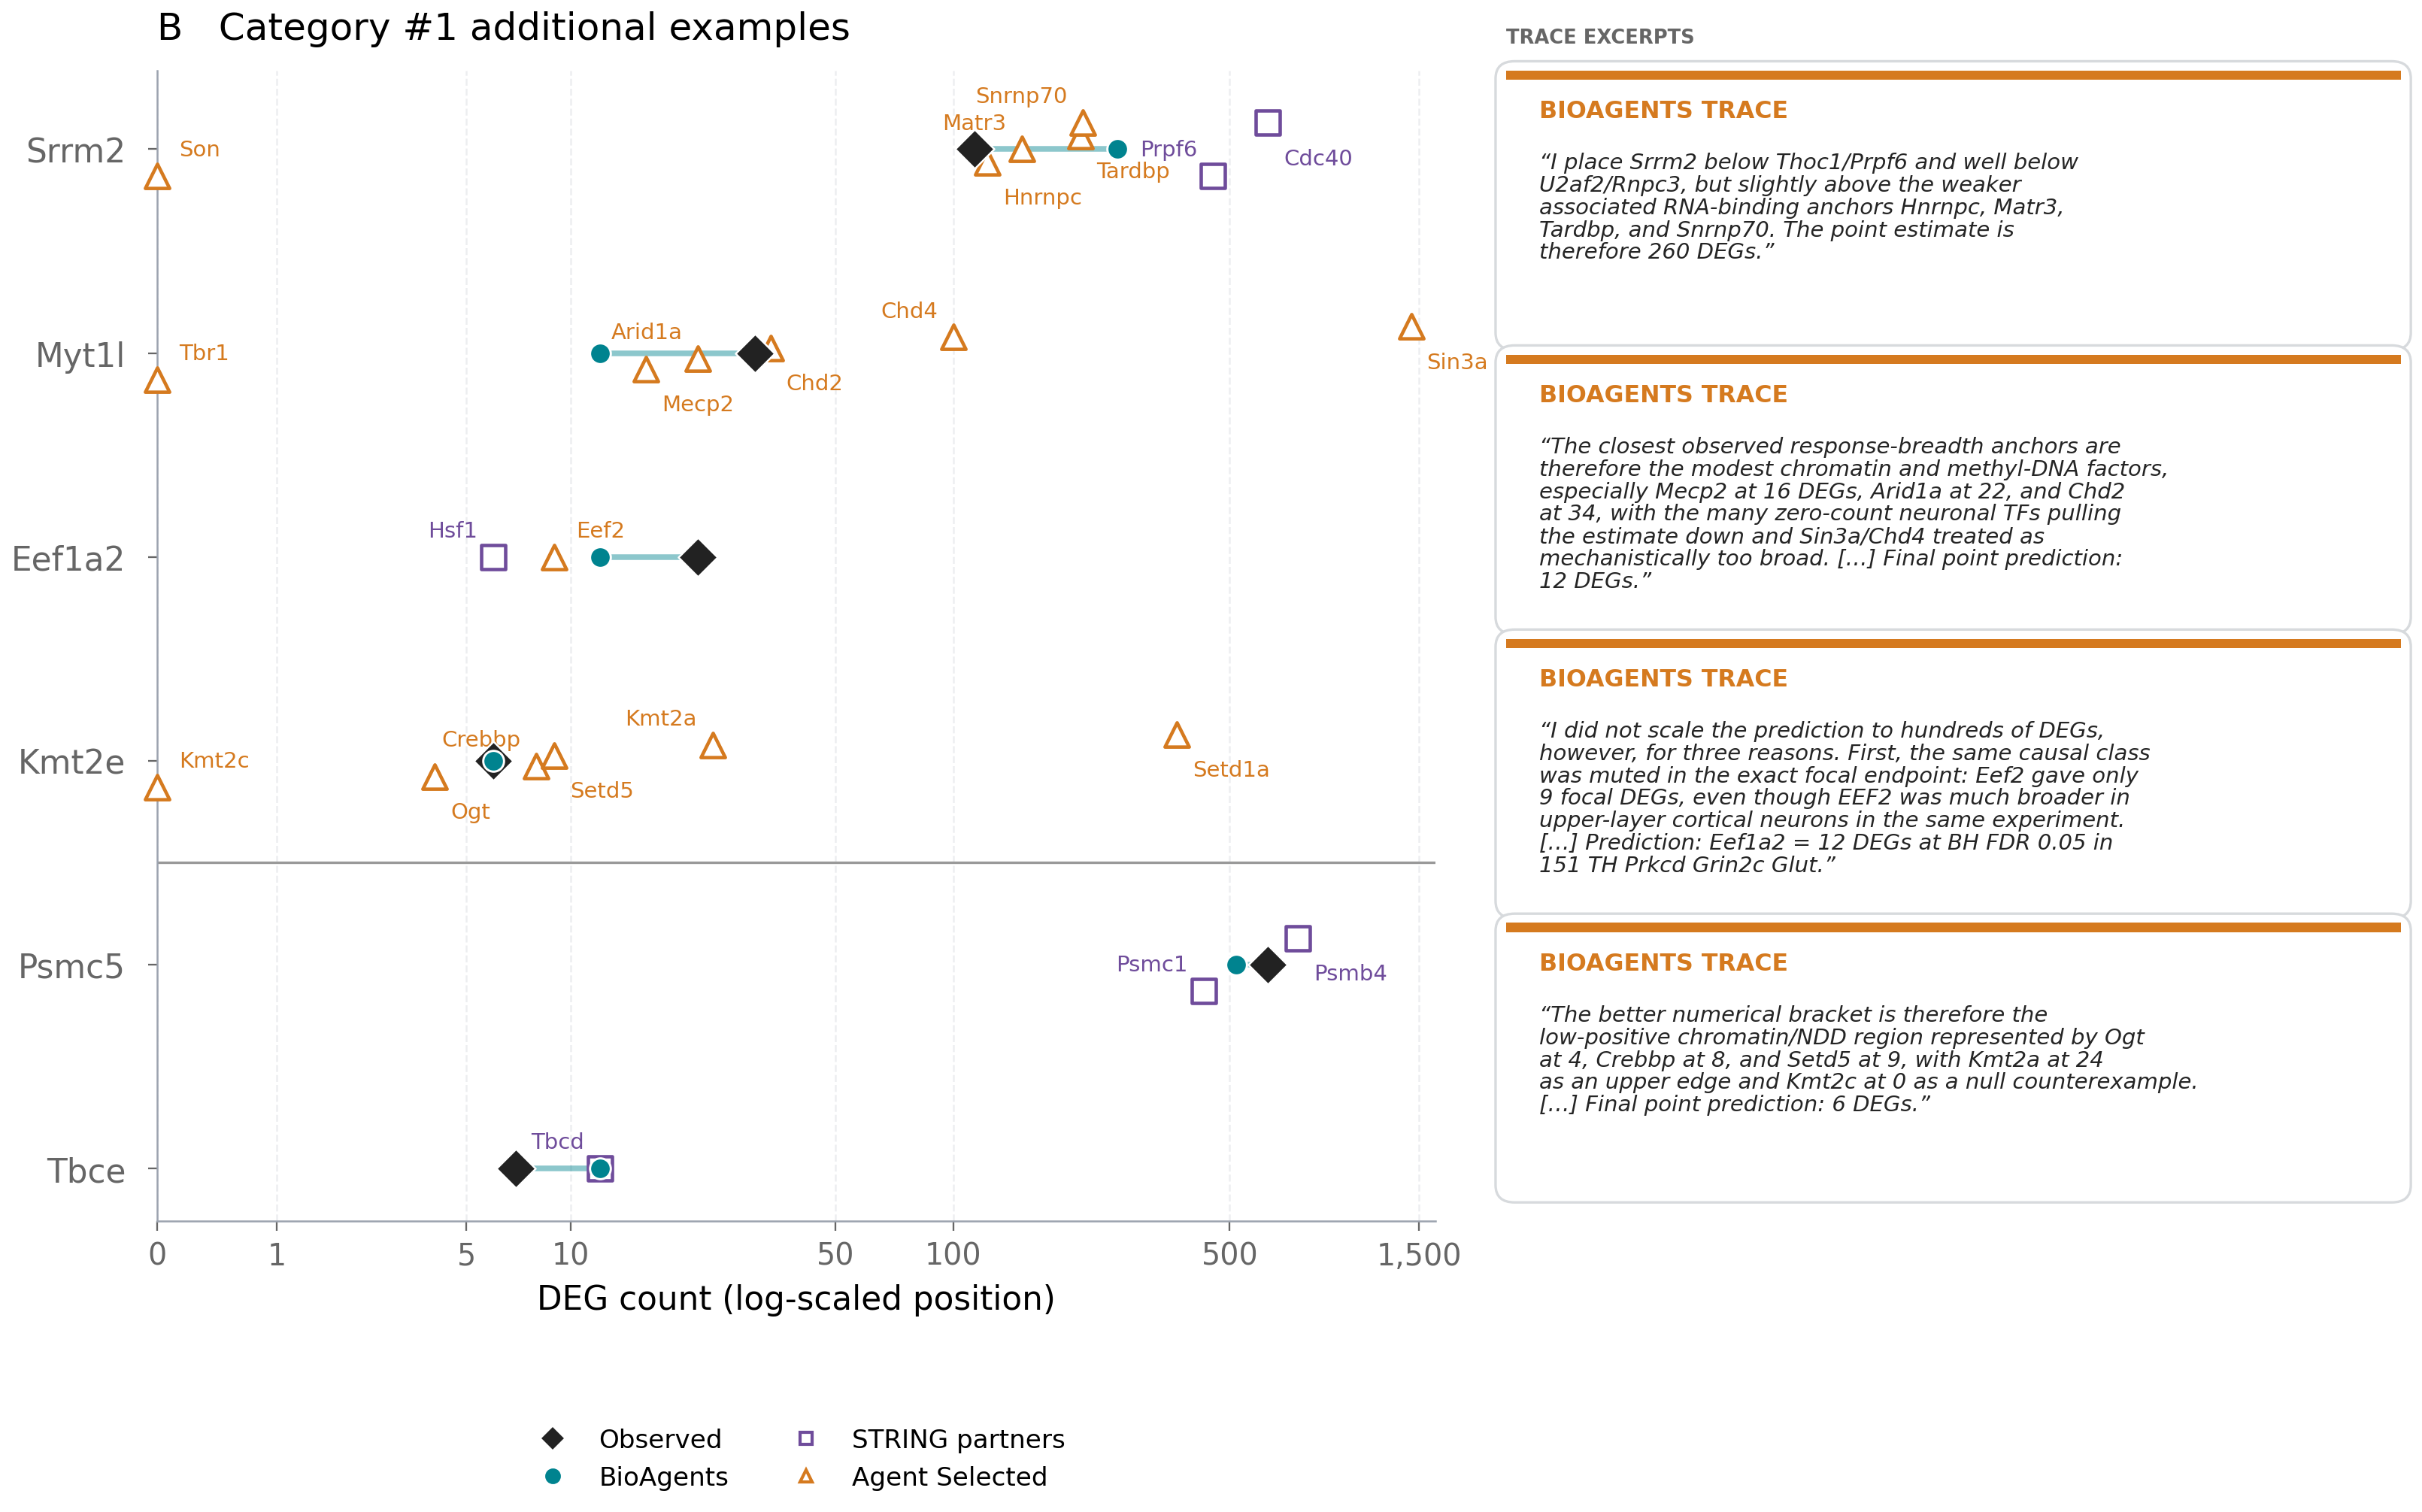

In [3]:
CASES = (
    {
        "target": "Srrm2",
        "direct": ("Prpf6", "Cdc40"),
        "alternative": ("Son", "Hnrnpc", "Matr3", "Tardbp", "Snrnp70"),
    },
    {
        "target": "Myt1l",
        "direct": (),
        "alternative": ("Tbr1", "Mecp2", "Arid1a", "Chd2", "Chd4", "Sin3a"),
    },
    {"target": "Eef1a2", "direct": ("Hsf1",), "alternative": ("Eef2",)},
    {
        "target": "Kmt2e",
        "direct": (),
        "alternative": ("Kmt2c", "Ogt", "Crebbp", "Setd5", "Kmt2a", "Setd1a"),
    },
    {"target": "Psmc5", "direct": ("Psmc1", "Psmb4"), "alternative": ()},
    {"target": "Tbce", "direct": ("Tbcd",), "alternative": ()},
)
TRACE_CARDS = {
    "Srrm2": (
        "“I place Srrm2 below Thoc1/Prpf6 and well below\n"
        "U2af2/Rnpc3, but slightly above the weaker\n"
        "associated RNA-binding anchors Hnrnpc, Matr3,\n"
        "Tardbp, and Snrnp70. The point estimate is\n"
        "therefore 260 DEGs.”"
    ),
    "Myt1l": (
        "“The closest observed response-breadth anchors are\n"
        "therefore the modest chromatin and methyl-DNA factors,\n"
        "especially Mecp2 at 16 DEGs, Arid1a at 22, and Chd2\n"
        "at 34, with the many zero-count neuronal TFs pulling\n"
        "the estimate down and Sin3a/Chd4 treated as\n"
        "mechanistically too broad. […] Final point prediction:\n"
        "12 DEGs.”"
    ),
    "Eef1a2": (
        "“I did not scale the prediction to hundreds of DEGs,\n"
        "however, for three reasons. First, the same causal class\n"
        "was muted in the exact focal endpoint: Eef2 gave only\n"
        "9 focal DEGs, even though EEF2 was much broader in\n"
        "upper-layer cortical neurons in the same experiment.\n"
        "[…] Prediction: Eef1a2 = 12 DEGs at BH FDR 0.05 in\n"
        "151 TH Prkcd Grin2c Glut.”"
    ),
    "Kmt2e": (
        "“The better numerical bracket is therefore the\n"
        "low-positive chromatin/NDD region represented by Ogt\n"
        "at 4, Crebbp at 8, and Setd5 at 9, with Kmt2a at 24\n"
        "as an upper edge and Kmt2c at 0 as a null counterexample.\n"
        "[…] Final point prediction: 6 DEGs.”"
    ),
}
ACTUAL_COLOR = "#222222"
STRING_COLOR = "#6F4C9B"
ALTERNATIVE_COLOR = "#D57A1F"


def annotate_comparators(ax, names, counts, y, color, marker):
    if not names:
        return
    jitter = np.linspace(-0.13, 0.13, len(names)) if len(names) > 1 else [0.0]
    for index, (name, dy) in enumerate(zip(names, jitter)):
        x = np.log1p(counts[name])
        ax.scatter(
            x, y + dy, s=60, marker=marker, facecolor="white",
            edgecolor=color, linewidth=1.1, clip_on=False, zorder=4,
        )
        vertical = 5 if index % 2 == 0 else -8
        if counts[name] == 0 or (len(names) == 1 and marker == "^"):
            horizontal = 7
        else:
            horizontal = -5 if index % 2 == 0 else 5
        ax.annotate(
            name, (x, y + dy), xytext=(horizontal, vertical),
            textcoords="offset points",
            ha="right" if horizontal < 0 else "left",
            va="bottom" if vertical > 0 else "top",
            fontsize=7, color=color, clip_on=False,
        )


def draw_trace_card(ax, target, card_index):
    x, width, height, gap = 1.055, 0.70, 0.235, 0.012
    y0 = 1.0 - height - card_index * (height + gap)
    ax.add_patch(
        FancyBboxPatch(
            (x, y0), width, height,
            boxstyle="round,pad=0.008,rounding_size=0.015",
            transform=ax.transAxes, facecolor="white", edgecolor="#D7DADD",
            linewidth=0.8, clip_on=False, zorder=8,
        )
    )
    ax.add_patch(
        Rectangle(
            (x, y0 + height - 0.008), width, 0.008,
            transform=ax.transAxes, facecolor=ALTERNATIVE_COLOR,
            edgecolor="none", clip_on=False, zorder=9,
        )
    )
    ax.text(
        x + 0.026, y0 + height - 0.025, "BIOAGENTS TRACE",
        transform=ax.transAxes, ha="left", va="top", fontsize=7.6,
        fontweight="bold", color=ALTERNATIVE_COLOR, clip_on=False, zorder=10,
    )
    ax.text(
        x + 0.026, y0 + height - 0.071, TRACE_CARDS[target],
        transform=ax.transAxes, ha="left", va="top", fontsize=7.0,
        fontstyle="italic", linespacing=1.08, color="#252525",
        clip_on=False, zorder=10,
    )


performance = B_TASK1.set_index("target_name")
training_counts = B_TRAINING.set_index("target_name")["n_degs"].astype(int).to_dict()
fig_b, ax = plt.subplots(figsize=(14.0, 7.5))
fig_b.subplots_adjust(left=0.09, right=0.60, bottom=0.20, top=0.88)

for row_index, case in enumerate(CASES):
    target = case["target"]
    actual = int(performance.loc[target, "actual_n_degs"])
    predicted = int(performance.loc[target, "bioagents_predicted_n_degs"])
    y = float(len(CASES) - 1 - row_index)
    actual_x, predicted_x = np.log1p(actual), np.log1p(predicted)
    ax.plot(
        [actual_x, predicted_x], [y, y], color=CHROME["bioagents"],
        alpha=0.45, linewidth=1.8, zorder=1,
    )
    annotate_comparators(
        ax, case["alternative"], training_counts, y, ALTERNATIVE_COLOR, "^"
    )
    annotate_comparators(
        ax, case["direct"], training_counts, y, STRING_COLOR, "s"
    )
    ax.scatter(
        actual_x, y, s=78, marker="D", facecolor=ACTUAL_COLOR,
        edgecolor="white", linewidth=0.6, clip_on=False, zorder=6,
    )
    ax.scatter(
        predicted_x, y, s=44, marker="o", facecolor=CHROME["bioagents"],
        edgecolor="white", linewidth=0.7, clip_on=False, zorder=7,
    )

for card_index, target in enumerate(TRACE_CARDS):
    draw_trace_card(ax, target, card_index)

ticks = np.asarray((0, 1, 5, 10, 50, 100, 500, 1500), dtype=float)
ax.set_xticks(np.log1p(ticks), [f"{int(value):,}" for value in ticks])
ax.set_xlim(0, np.log1p(1650))
ax.set_yticks(
    np.arange(len(CASES) - 1, -1, -1), [case["target"] for case in CASES]
)
ax.set_xlabel("DEG count (log-scaled position)", fontsize=10.5)
ax.axhline(1.5, color="#999999", linewidth=0.8)
clean_axis(ax, "x")
ax.tick_params(axis="x", labelsize=9.5)
ax.tick_params(axis="y", labelsize=10.5, pad=7)
ax.set_title("B   Category #1 additional examples", loc="left", fontsize=12, pad=10)
ax.text(
    1.055, 1.02, "TRACE EXCERPTS", transform=ax.transAxes,
    ha="left", va="bottom", fontsize=6.2, fontweight="bold",
    color=CHROME["muted"], clip_on=False,
)
ax.legend(
    handles=[
        Line2D([], [], marker="D", linestyle="", color=ACTUAL_COLOR, label="Observed"),
        Line2D([], [], marker="o", linestyle="", color=CHROME["bioagents"], label="BioAgents"),
        Line2D([], [], marker="s", linestyle="", markerfacecolor="white", color=STRING_COLOR, label="STRING partners"),
        Line2D([], [], marker="^", linestyle="", markerfacecolor="white", color=ALTERNATIVE_COLOR, label="Agent Selected"),
    ],
    frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.16),
    ncol=2, fontsize=8.2,
)
ax.set_box_aspect(0.90)
fig_b;


## Supplementary Figure 10C

Training-set neighbors of the overcalled targets, separated into
functional, physical, and literature-derived STRING relationships.
Colors distinguish absent qualifying neighbors, exclusively zero-response
neighbors, and cells containing at least one responding neighbor.


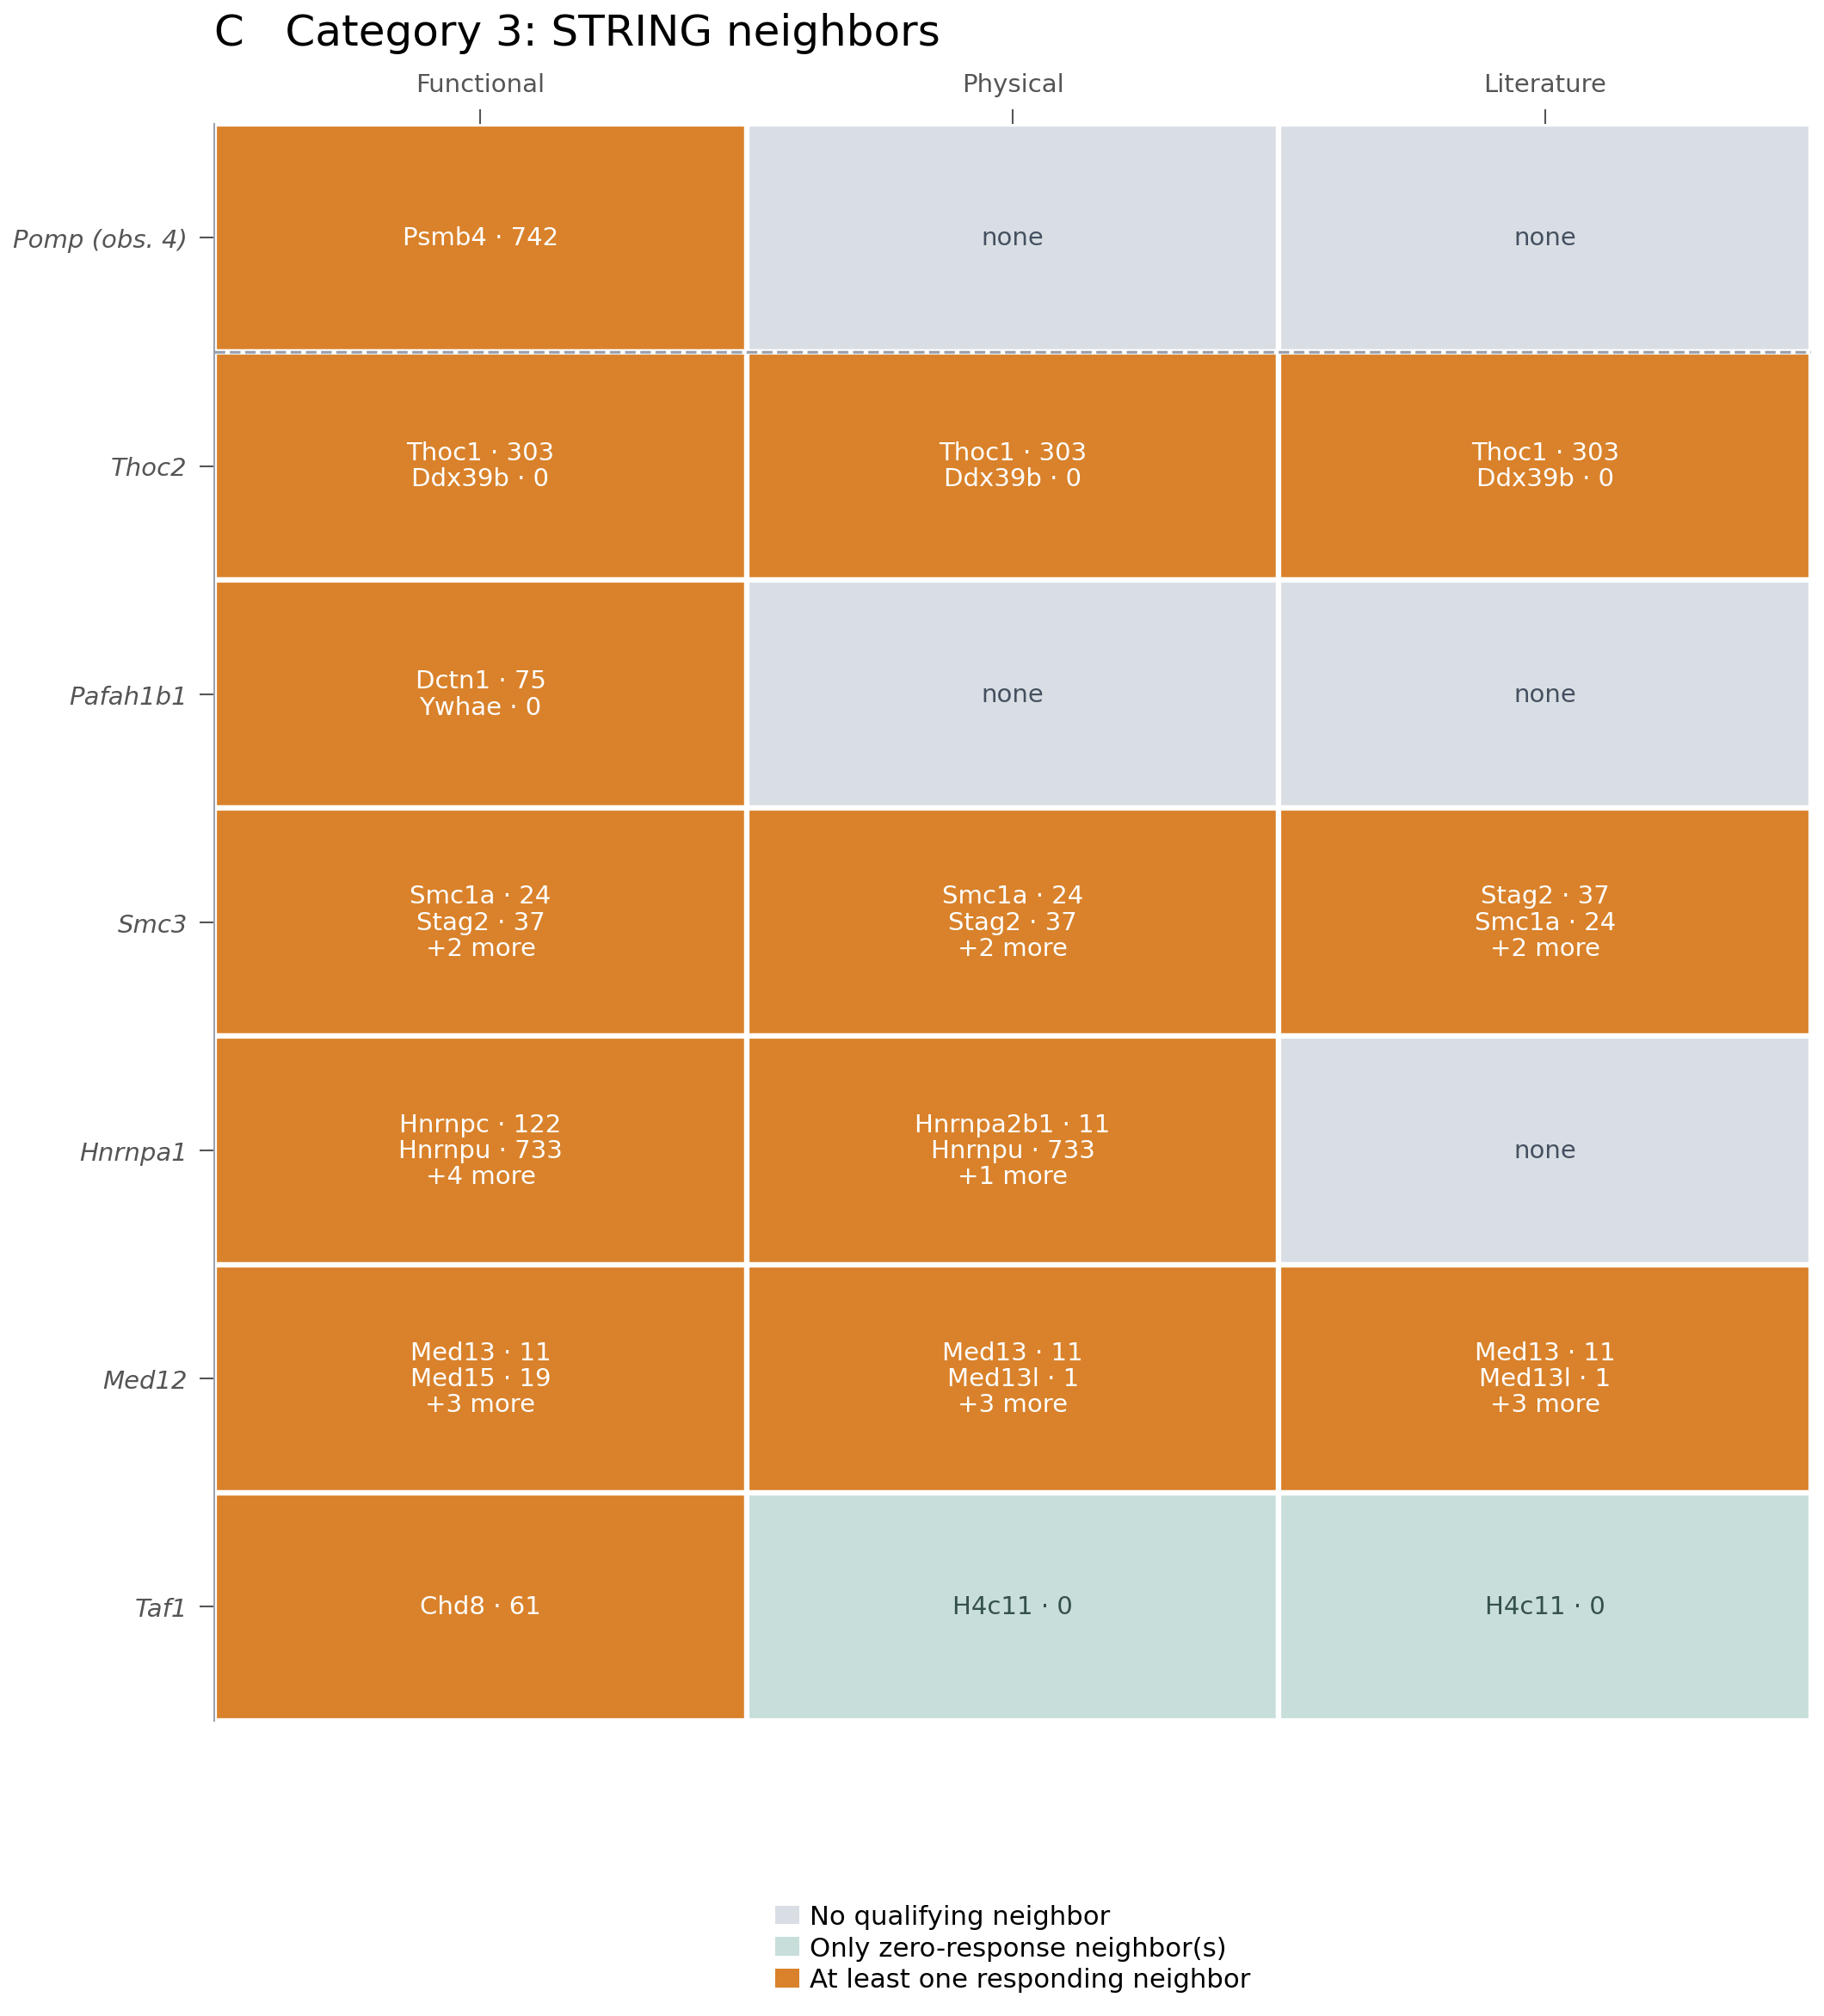

In [4]:
NETWORK_ORDER = ("functional", "physical", "literature")
NETWORK_LABELS = {
    "functional": "Functional", "physical": "Physical", "literature": "Literature"
}
STATUS_COLORS = {
    "none": "#D9DEE5", "zero_only": "#C8DEDA", "responding": "#D9822B"
}
STATUS_LABELS = {
    "none": "No qualifying neighbor",
    "zero_only": "Only zero-response neighbor(s)",
    "responding": "At least one responding neighbor",
}


def string_status(rows):
    if rows.empty:
        return "none"
    return "responding" if rows["partner_responds"].any() else "zero_only"


fig_c, ax = plt.subplots(figsize=(7.2, 7.6))
targets = C_FEATURED["target_name"].tolist()
for row, target in enumerate(targets):
    for col, network in enumerate(NETWORK_ORDER):
        neighbors = C_NEIGHBORS[
            C_NEIGHBORS["p"].eq(target) & C_NEIGHBORS["network"].eq(network)
        ]
        status = string_status(neighbors)
        ax.add_patch(
            Rectangle(
                (col - 0.5, row - 0.5), 1, 1,
                facecolor=STATUS_COLORS[status], edgecolor="white", linewidth=1.5,
            )
        )
        if status == "none":
            label, text_color = "none", "#44505F"
        else:
            lines = [
                f"{record.q} · {int(record.partner_n_degs):,}"
                for record in neighbors.head(2).itertuples(index=False)
            ]
            remaining = len(neighbors) - min(2, len(neighbors))
            if remaining:
                lines.append(f"+{remaining} more")
            label = "\n".join(lines)
            text_color = "white" if status == "responding" else "#35514D"
        ax.text(
            col, row, label, ha="center", va="center", fontsize=7.0,
            color=text_color, linespacing=1.10,
        )

ax.set_xticks(range(3), [NETWORK_LABELS[n] for n in NETWORK_ORDER])
ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False)
ax.set_yticks(range(len(targets)), C_FEATURED["display_name"])
for label in ax.get_yticklabels():
    label.set_fontstyle("italic")
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(len(targets) - 0.5, -0.5)
ax.axhline(0.5, color=CHROME["axis"], linewidth=0.8, linestyle="--", zorder=5)
ax.set_title("C   Category 3: STRING neighbors", loc="left", fontsize=12, pad=22)
ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.spines["left"].set_color(CHROME["axis"])
ax.legend(
    handles=[
        Patch(facecolor=STATUS_COLORS[status], edgecolor="none", label=STATUS_LABELS[status])
        for status in ("none", "zero_only", "responding")
    ],
    loc="upper center", bbox_to_anchor=(0.5, -0.10), frameon=False,
    fontsize=7.4, ncol=1, handlelength=0.9, handletextpad=0.4, labelspacing=0.25,
)
ax.set_box_aspect(1)
fig_c.tight_layout()
fig_c;


## Supplementary Figure 10D

Prediction error across recovered-cell and depletion strata.

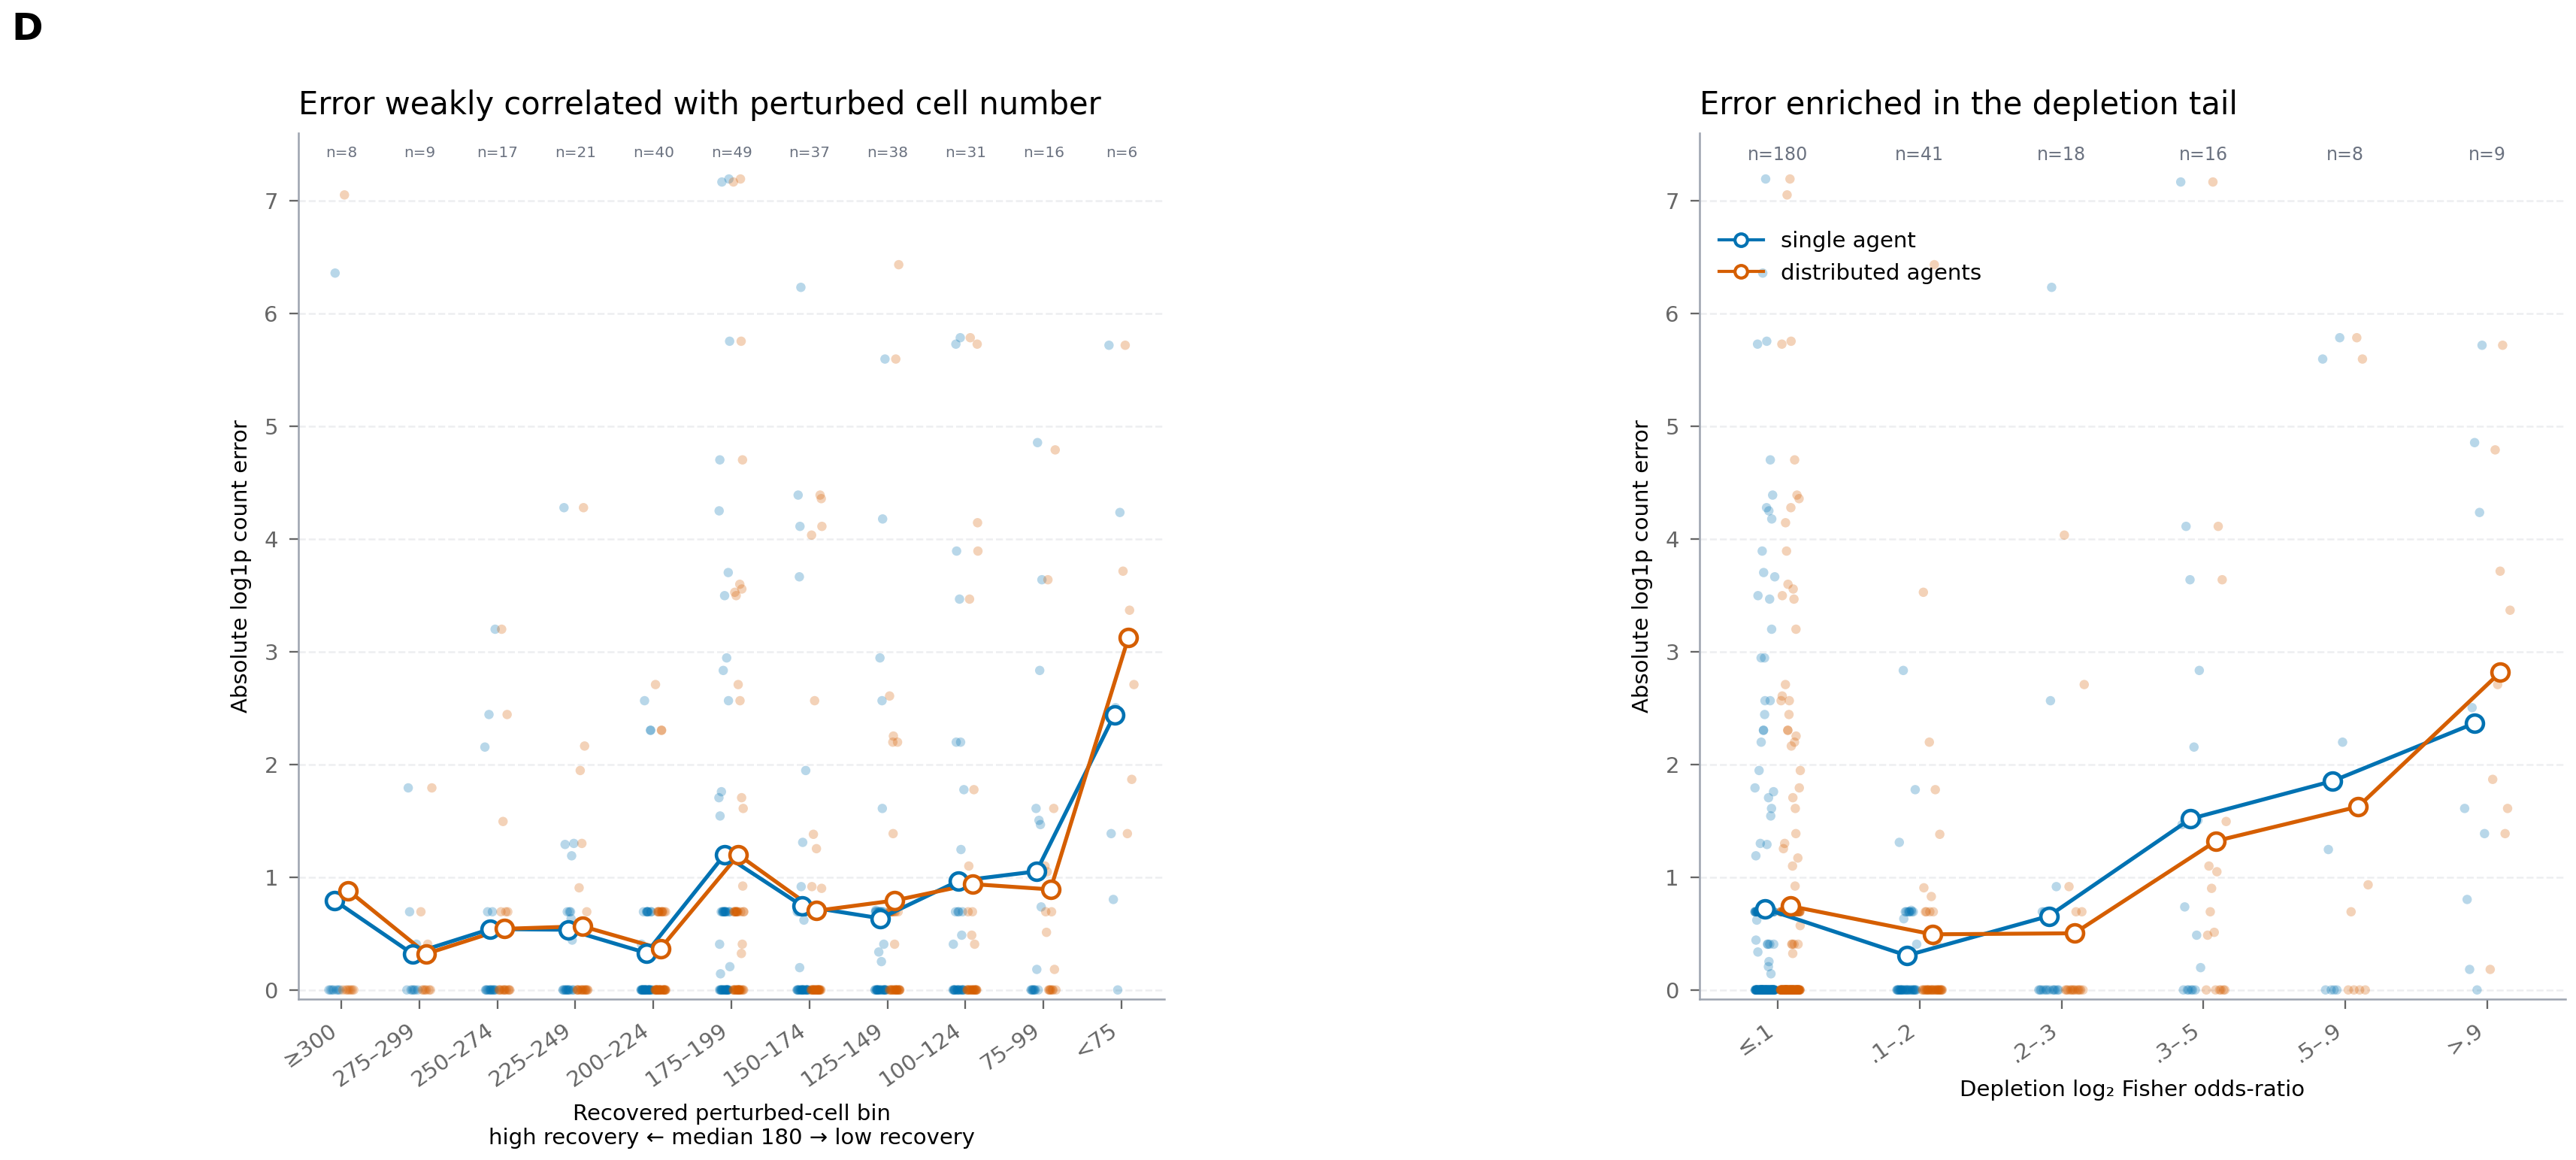

In [5]:
SYSTEMS = {
    "single agent": ("codex_predicted_n_degs", "#0072B2"),
    "distributed agents": ("bioagents_predicted_n_degs", "#D55E00"),
}
DEPLETION_ORDER = ["reference", "0.1–0.2", "0.2–0.3", "0.3–0.5", "0.5–0.9", ">0.9"]
DEPLETION_LABELS = ["≤.1", ".1–.2", ".2–.3", ".3–.5", ".5–.9", ">.9"]
CELL_ORDER = [
    "≥300", "275–299", "250–274", "225–249", "200–224", "175–199",
    "150–174", "125–149", "100–124", "75–99", "<75",
]


def deterministic_jitter(n, group_index, system_index):
    if n <= 1:
        return np.zeros(n)
    base = np.linspace(-0.07, 0.07, n)
    shift = (group_index * 17 + system_index * 11) % n
    return np.roll(base, shift)


def draw_grouped_metric(
    ax, frame, group_column, group_order, group_labels, title, xlabel, legend
):
    x = np.arange(len(group_order), dtype=float)
    offsets = {"single agent": -0.09, "distributed agents": 0.09}
    for system_index, (system, (_, color)) in enumerate(SYSTEMS.items()):
        means, raw_x, raw_y = [], [], []
        for group_index, group in enumerate(group_order):
            values = frame.loc[
                frame[group_column].eq(group), f"{system}_absolute_log1p_error"
            ].to_numpy(dtype=float)
            means.append(float(values.mean()))
            raw_x.extend(
                group_index + offsets[system]
                + deterministic_jitter(len(values), group_index, system_index)
            )
            raw_y.extend(values)
        ax.scatter(
            raw_x, raw_y, s=9, color=color, alpha=0.28,
            edgecolor="none", rasterized=True, zorder=1,
        )
        xpos = x + offsets[system]
        ax.plot(xpos, means, color=color, linewidth=1.25, zorder=2)
        ax.scatter(
            xpos, means, s=30, facecolor="white", edgecolor=color,
            linewidth=1.1, clip_on=False, zorder=3,
        )
    counts = frame[group_column].value_counts()
    count_fontsize = 4.8 if len(group_order) > 8 else 5.7
    for xpos, group in zip(x, group_order):
        ax.text(
            xpos, 0.985, f"n={int(counts[group])}",
            transform=ax.get_xaxis_transform(), ha="center", va="top",
            fontsize=count_fontsize, color="#6B7280",
        )
    ax.set_xticks(x, group_labels)
    ax.tick_params(axis="x", labelrotation=35)
    for label in ax.get_xticklabels():
        label.set_ha("right")
    ax.set_xlim(-0.55, len(group_order) - 0.45)
    ax.set_ylim(-0.08, 7.6)
    ax.set_ylabel("Absolute log1p count error")
    ax.set_xlabel(xlabel)
    ax.set_title(title, loc="left", fontsize=10)
    clean_axis(ax, "y")
    ax.set_box_aspect(1)
    if legend:
        ax.legend(
            handles=[
                Line2D(
                    [], [], marker="o", linestyle="-", markerfacecolor="white",
                    markeredgecolor=color, color=color, label=system,
                )
                for system, (_, color) in SYSTEMS.items()
            ],
            loc="upper left", bbox_to_anchor=(0.0, 0.91), frameon=False,
        )


frame = D_HOLDOUTS.copy()
for system, (prediction_column, _) in SYSTEMS.items():
    frame[f"{system}_absolute_log1p_error"] = np.abs(
        np.log1p(frame[prediction_column]) - np.log1p(frame["actual_n_degs"])
    )
frame["depletion_stratum"] = pd.cut(
    frame["log2_depletion_odds_ratio"],
    bins=[-np.inf, 0.1, 0.2, 0.3, 0.5, 0.9, np.inf],
    labels=DEPLETION_ORDER, include_lowest=True,
).astype(str)
frame["cell_bin"] = pd.cut(
    frame["recovered_perturbed_cells"],
    bins=[-np.inf, 74, 99, 124, 149, 174, 199, 224, 249, 274, 299, np.inf],
    labels=[
        "<75", "75–99", "100–124", "125–149", "150–174", "175–199",
        "200–224", "225–249", "250–274", "275–299", "≥300",
    ],
    include_lowest=True,
).astype(str)

fig_d, axes = plt.subplots(1, 2, figsize=(12.0, 6.0))
fig_d.subplots_adjust(left=0.08, right=0.99, bottom=0.22, top=0.86, wspace=0.32)
fig_d.text(0.01, 0.95, "D", fontsize=12, fontweight="bold", ha="left", va="top")
draw_grouped_metric(
    axes[0], frame, "cell_bin", CELL_ORDER, CELL_ORDER,
    "Error weakly correlated with perturbed cell number",
    "Recovered perturbed-cell bin\nhigh recovery ← median 180 → low recovery",
    False,
)
draw_grouped_metric(
    axes[1], frame, "depletion_stratum", DEPLETION_ORDER, DEPLETION_LABELS,
    "Error enriched in the depletion tail",
    "Depletion log₂ Fisher odds-ratio",
    True,
)
fig_d;


## Supplementary Figure 10E

Observed versus AAV-pool-expected perturbed-cell recovery in thalamic
glutamatergic neurons. The diagonal denotes equal observed and expected
recovery; color shows Fisher depletion magnitude for the top 100 targets.


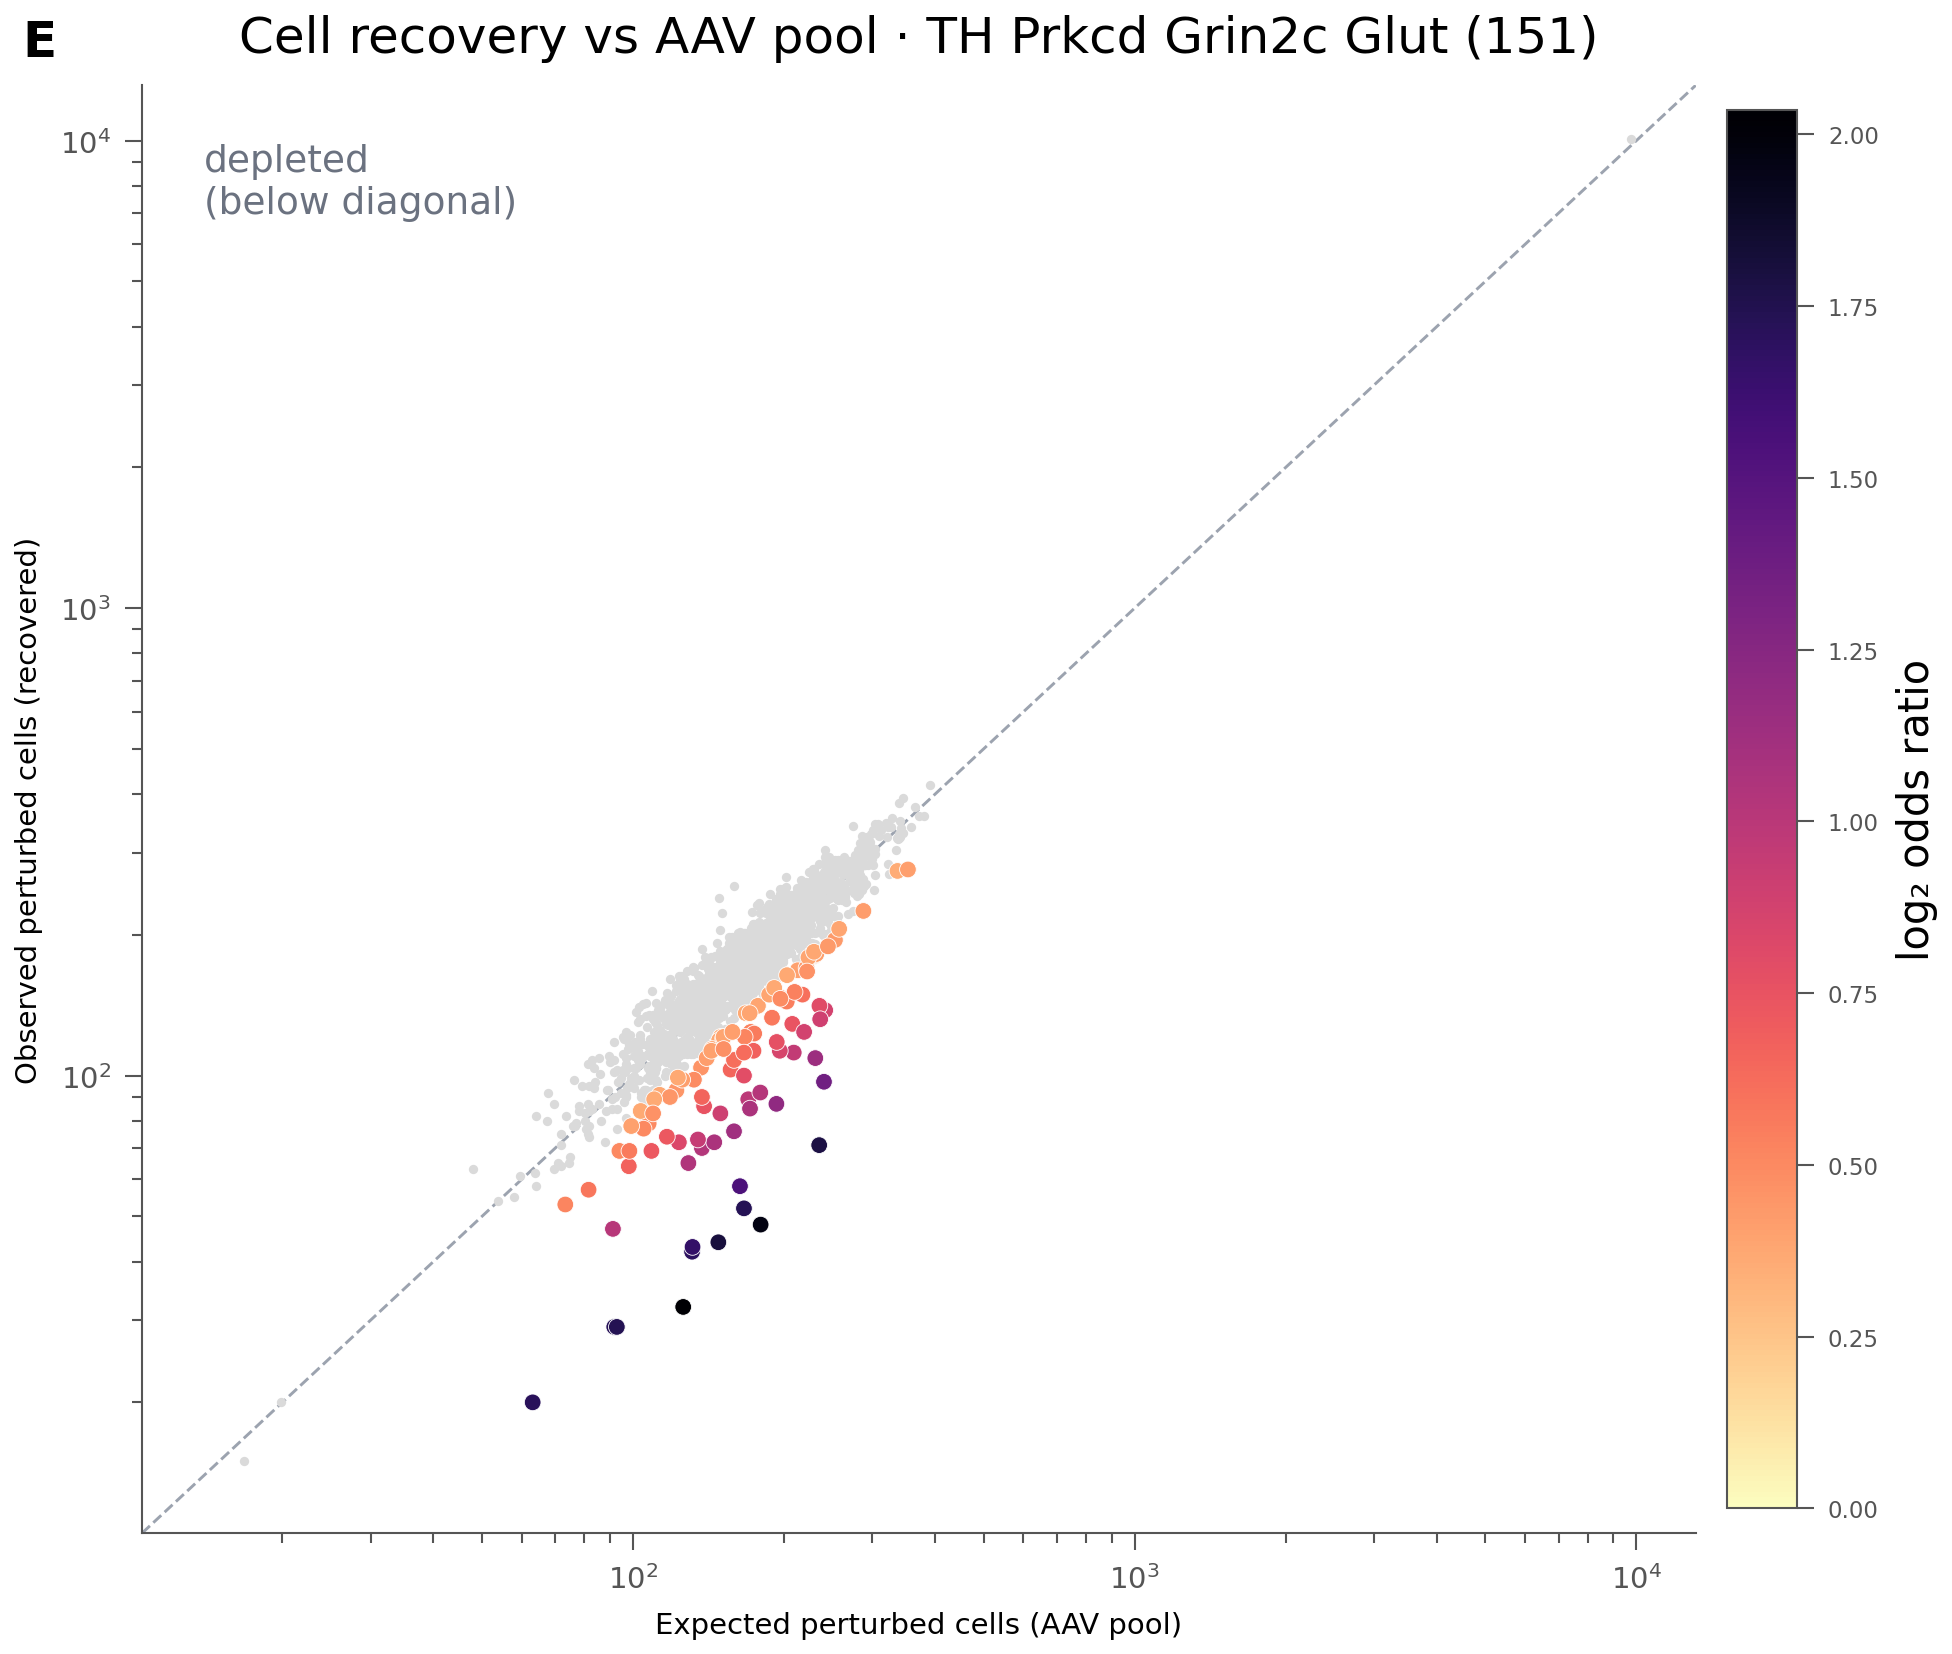

In [6]:
fisher = E_FISHER.rename(
    columns={
        "observed_pert_in_T (b)": "observed",
        "expected_pert_in_T (a)": "expected",
    }
).copy()
fisher["log2_or"] = np.log2(fisher["odds_ratio"].where(fisher["odds_ratio"].gt(0)))
top100 = set(E_TOP150.loc[E_TOP150["depletion_rank"].le(100), "gene_target"])
is_top100 = fisher["gene_target"].isin(top100)
assert is_top100.sum() == 100

fig_e, ax = plt.subplots(figsize=(6.5, 5.5), layout="constrained")
limits = [
    fisher[["observed", "expected"]].to_numpy().min() * 0.7,
    fisher[["observed", "expected"]].to_numpy().max() * 1.3,
]
ax.plot(limits, limits, color="#9CA3AF", linestyle="--", linewidth=0.7, zorder=1)
ax.scatter(
    fisher.loc[~is_top100, "expected"],
    fisher.loc[~is_top100, "observed"],
    s=5, color="#DADADA", linewidth=0, zorder=2,
)
points = ax.scatter(
    fisher.loc[is_top100, "expected"],
    fisher.loc[is_top100, "observed"],
    s=16, c=fisher.loc[is_top100, "log2_or"], cmap="magma_r", vmin=0,
    edgecolor="white", linewidth=0.2, zorder=3,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(limits)
ax.set_ylim(limits)
ax.set_xlabel("Expected perturbed cells (AAV pool)")
ax.set_ylabel("Observed perturbed cells (recovered)")
ax.set_title("Cell recovery vs AAV pool · TH Prkcd Grin2c Glut (151)", fontsize=12, pad=8)
ax.text(
    0.04, 0.96, "depleted\n(below diagonal)", transform=ax.transAxes,
    va="top", ha="left", fontsize=9, color="#6B7280",
)
colorbar = fig_e.colorbar(points, ax=ax, fraction=0.045, pad=0.02)
colorbar.set_label("log₂ odds ratio", fontsize=10)
colorbar.ax.tick_params(labelsize=5.5)
fig_e.text(0.01, 0.99, "E", ha="left", va="top", fontsize=12, fontweight="bold")
fig_e;
